# Task 1 — EDA & Preprocessing (polars)

Explore the CFPB complaint dataset, filter to the four target products, clean the
narratives, and save `data/processed/filtered_complaints.csv`.

> **Kernel:** select **Python (rag-complaint-chatbot)** (the project `.venv`).
> The raw file is a ~5.6 GB CSV with a malformed quote that crashes pandas, so we
> use **polars** with a lazy scan over a Parquet cache (column pushdown keeps memory low).

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `import src...` works inside the notebook
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

from src import data_processing as dp

sns.set_theme(style="whitegrid")
print("polars", pl.__version__)

polars 1.41.2


## 1. Load the full dataset

We *lazily* scan the raw CSV. Nothing is read until a `.collect()` happens, and
polars only reads the columns each step needs.

In [2]:
RAW_PATH = dp.RAW_DATA_DIR / "complaints.csv"  # <-- update filename if different

# One-time: cache the ~5.6 GB CSV as columnar Parquet (~40s, ~2 GB peak).
# CSV isn't seekable, so every polars query would otherwise read the whole
# file into RAM (~5.7 GB). Parquet lets later scans read only needed columns.
PARQUET_PATH = dp.convert_to_parquet(RAW_PATH)
print(f"Parquet cache: {PARQUET_PATH}")

lf = dp.scan_complaints(PARQUET_PATH)
n_rows = lf.select(pl.len()).collect().item()
print(f"Total rows: {n_rows:,}")
lf.head().collect()

Parquet cache: /home/kalkidan_fantu/tenx/kaim/rag-complaint-chatbot/data/processed/complaints.parquet
Total rows: 9,609,797


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Incorrect information on your …","""Information belongs to someone…",null,null,"""Experian Information Solutions…","""FL""","""32092""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""","""N/A""","""14195687"""
"""2025-06-20""","""Debt collection""","""Telecommunications debt""","""Attempts to collect debt not o…","""Debt is not yours""",null,"""Company can't verify or disput…","""Eastern Account Systems of Con…","""FL""","""342XX""",null,null,"""Web""","""2025-06-20""","""Closed with explanation""","""Yes""","""N/A""","""14195688"""
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Improper use of your report""","""Reporting company used your re…",null,null,"""TRANSUNION INTERMEDIATE HOLDIN…","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""","""N/A""","""14195689"""
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Improper use of your report""","""Reporting company used your re…",null,null,"""Experian Information Solutions…","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""","""N/A""","""14195690"""
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Incorrect information on your …","""Account status incorrect""",null,null,"""Experian Information Solutions…","""IL""","""60628""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""","""N/A""","""14195692"""


## 2. Initial EDA

### 2a. Distribution of complaints across products

shape: (21, 2)
┌─────────────────────────────────┬─────────┐
│ Product                         ┆ count   │
│ ---                             ┆ ---     │
│ str                             ┆ u32     │
╞═════════════════════════════════╪═════════╡
│ Credit reporting or other pers… ┆ 4834855 │
│ Credit reporting, credit repai… ┆ 2163857 │
│ Debt collection                 ┆ 799197  │
│ Mortgage                        ┆ 422254  │
│ Checking or savings account     ┆ 291178  │
│ …                               ┆ …       │
│ Payday loan                     ┆ 5541    │
│ Money transfers                 ┆ 5354    │
│ Debt or credit management       ┆ 5047    │
│ Other financial service         ┆ 1058    │
│ Virtual currency                ┆ 18      │
└─────────────────────────────────┴─────────┘


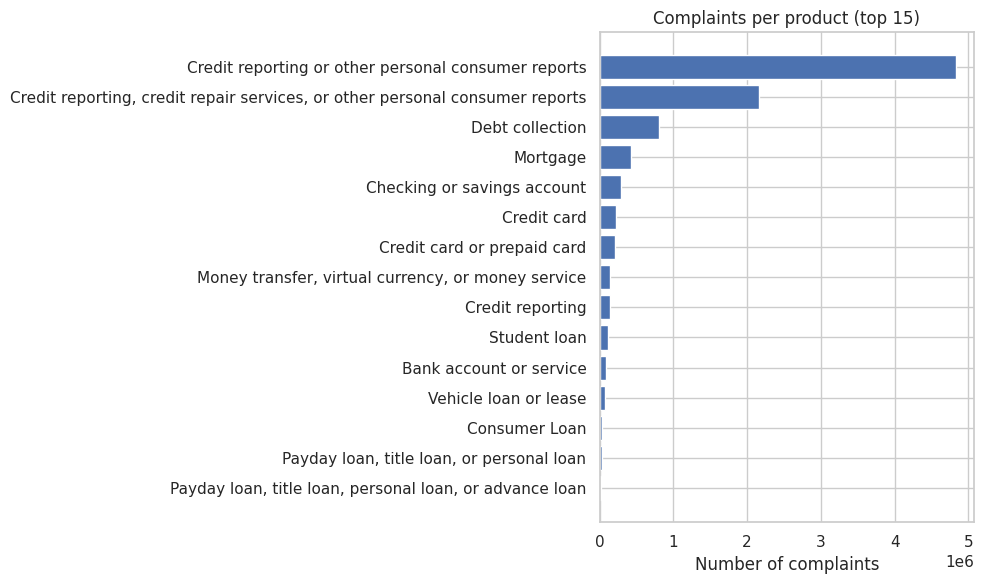

In [3]:
product_counts = dp.product_distribution(lf)
print(product_counts)

top = product_counts.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top[dp.PRODUCT_COL].to_list()[::-1], top["count"].to_list()[::-1])
plt.title("Complaints per product (top 15)")
plt.xlabel("Number of complaints")
plt.tight_layout()
plt.show()

### 2b. Consumer narrative length (word count)

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 9.609797e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 54.466666  │
│ std        ┆ 149.76725  │
│ min        ┆ 0.0        │
│ 25%        ┆ 0.0        │
│ 50%        ┆ 0.0        │
│ 75%        ┆ 50.0       │
│ max        ┆ 6469.0     │
└────────────┴────────────┘


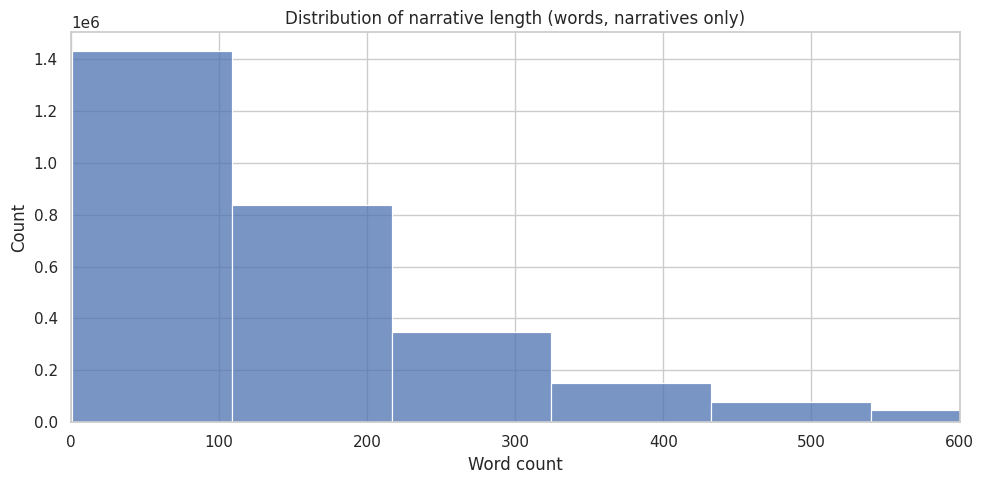

In [4]:
# Compute word counts lazily and keep ONLY the integer column
# (materializing all ~9.6M narrative strings would exhaust RAM).
wc = (
    lf.select(
        pl.col(dp.NARRATIVE_COL)
        .fill_null("")
        .str.count_matches(r"\S+")
        .alias("narrative_word_count")
    )
    .collect(engine="streaming")
)
print(wc["narrative_word_count"].describe())

vals = wc.filter(pl.col("narrative_word_count") > 0)["narrative_word_count"].to_numpy()
plt.figure(figsize=(10, 5))
sns.histplot(vals, bins=60)
plt.title("Distribution of narrative length (words, narratives only)")
plt.xlabel("Word count")
plt.xlim(0, 600)
plt.tight_layout()
plt.show()

### 2c. Complaints with vs. without narratives

{'with_narrative': 2980756, 'without_narrative': 6629041}


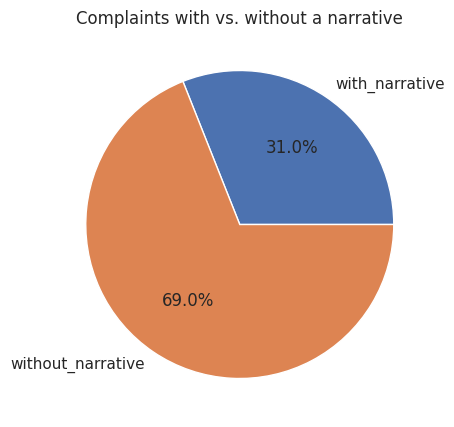

In [5]:
presence = dp.narrative_presence(lf)
print(presence)

plt.figure(figsize=(5, 5))
plt.pie(list(presence.values()), labels=list(presence.keys()), autopct="%1.1f%%")
plt.title("Complaints with vs. without a narrative")
plt.show()

## 3. Filter the dataset

Keep only the four target products and drop empty narratives. We select
`KEEP_COLS` first so the filtered output retains metadata (Complaint ID, Company,
State, ...) for later traceability.

In [6]:
filtered = dp.filter_complaints(lf.select(dp.KEEP_COLS))
print(f"Rows after filtering: {len(filtered):,}")
filtered["product_category"].value_counts(sort=True)

Rows after filtering: 463,933


product_category,count
str,u32
"""Credit Card""",189334
"""Savings Account""",140319
"""Money Transfer""",98685
"""Personal Loan""",35595


## 4. Clean the narratives

Lowercase, strip CFPB redactions (`XXXX`), remove boilerplate openers and special
characters, collapse whitespace.

In [7]:
cleaned = dp.clean_narratives(filtered)
print(f"Rows after cleaning: {len(cleaned):,}")

# Before / after example
row = cleaned.row(0, named=True)
print("RAW:\n", row[dp.NARRATIVE_COL][:300])
print("\nCLEANED:\n", row["cleaned_narrative"][:300])

Rows after cleaning: 463,929
RAW:
 A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However

CLEANED:
 a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confirmed this was fraudulent and immediately closed the card. however, they have failed to remove this fr


## 5. Save the cleaned, filtered dataset

In [8]:
out_path = dp.save_filtered(cleaned)
print(f"Saved {len(cleaned):,} complaints to {out_path}")

Saved 463,929 complaints to /home/kalkidan_fantu/tenx/kaim/rag-complaint-chatbot/data/processed/filtered_complaints.csv


## EDA Summary

**Dataset & product distribution.** The full CFPB export contains **9,609,797 complaints** across 18 columns and 21 raw product labels. The distribution is heavily skewed toward credit reporting: *"Credit reporting or other personal consumer reports"* (4.83M) and *"Credit reporting, credit repair..."* (2.16M) together account for ~73% of all records, followed by debt collection (799K) and mortgage (422K). The four products this project targets are a comparatively small slice of the corpus. After mapping the verbose raw labels to four canonical categories (e.g. both *"Credit card"* and *"Credit card or prepaid card"* map to **Credit Card**) and keeping only those products, **463,933** complaints remain, themselves imbalanced: **Credit Card 189,334**, **Savings Account 140,319**, **Money Transfer 98,685**, and **Personal Loan 35,595** — roughly a 5:1 ratio between the largest and smallest. This imbalance is the reason Task 2 uses *stratified* sampling rather than a naïve random sample.

**Narrative presence.** Only **31.0%** of complaints (2,980,756) include a free-text consumer narrative; the remaining **6,629,041 (69%)** have an empty narrative field. Since the RAG system can only reason over text it can read, the narrative is the scarce, high-value signal, and complaints without one are dropped entirely. This is a major filter: the usable corpus is less than a third of the raw row count.

**Narrative length.** Among complaints that have a narrative, length is **right-skewed with a long tail**: mean ≈ **176 words**, median **114**, interquartile range **59–209**, but the 95th percentile reaches **519** and the maximum is **6,469** words. About **4.2%** are very short (<20 words, often too thin to be informative) and **14.2%** are long (>300 words). Embedding a 1,000-word narrative as a single vector would blur many distinct issues together, which directly motivates the chunking strategy in Task 2 (500-character chunks with 50-character overlap).

**Cleaning decisions.** Each narrative is lowercased; CFPB redaction placeholders (`XXXX`, run-length `x` sequences) are stripped; common boilerplate openers (e.g. *"I am writing to file a complaint..."*) are removed; non-essential special characters are dropped and whitespace collapsed. Note that removing `XXXX` also deletes redacted names, companies, and dollar amounts — a deliberate choice, since those tokens carry no semantic value and would only add noise to the embeddings. The before/after example shows the redaction tokens and filler gone while the substance (fraudulent card opened, unauthorized account) is preserved. **4 records** became empty after cleaning and were dropped, leaving **463,929** complaints in `filtered_complaints.csv`.